
# HQNN-Parallel: simulador ideal, IBM Quantum e propagação de ruído

Este notebook implementa uma versão concisa do HQNN-Parallel de Senokosov et al. para MNIST.

O fluxo é:

\[
\text{imagem}
\rightarrow
\text{CNN clássica}
\rightarrow
1568
\rightarrow
20
\rightarrow
4\times 5\text{ qubits}
\rightarrow
20
\rightarrow
10\text{ classes}.
\]

Serão feitos dois treinamentos partindo exatamente da mesma inicialização:

1. **Treinamento ideal:** circuito quântico simulado sem ruído.
2. **Treinamento com ruído IBM:** o erro empírico medido em um computador quântico real é injetado na saída da camada quântica durante o treinamento.

Também são incluídas células para salvar e carregar modelos, histórico completo de treinamento e medições da IBM Quantum.



## 1. Bibliotecas e configuração

O simulador ideal usa `lightning.gpu`. A parte clássica e o simulador quântico são executados em CUDA.


In [1]:

import json
import copy
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import pennylane as qml

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda")
print(torch.cuda.get_device_name(0))


NVIDIA H100 PCIe


In [2]:

BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-3
N_TRAIN = 2000
N_TEST = 500
N_QUBITS = 5
N_LAYERS = 3
N_CIRCUITS = 4
N_QFEATURES = N_QUBITS * N_CIRCUITS

OUTDIR = Path("hqnn_runs")
OUTDIR.mkdir(exist_ok=True)



## 2. MNIST

Para uma apresentação rápida, o notebook usa 2000 imagens de treino e 500 de teste. Para usar o conjunto completo, basta definir `N_TRAIN = 60000` e `N_TEST = 10000`.


In [3]:

transform = transforms.ToTensor()

train_full = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_full = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_dataset = Subset(train_full, range(N_TRAIN))
test_dataset = Subset(test_full, range(N_TEST))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_dataset), len(test_dataset))


2000 500



## 3. Modelo HQNN-Parallel

A CNN reduz a imagem para:

\[
32\times7\times7=1568
\]

características. Uma camada densa comprime:

\[
1568\rightarrow20.
\]

Os 20 valores são divididos em quatro circuitos de 5 qubits. Cada circuito retorna cinco valores de expectativa \(\langle Y\rangle\).


In [4]:

qdev = qml.device("lightning.gpu", wires=N_QUBITS, shots=None)

@qml.qnode(qdev, interface="torch", diff_method="adjoint")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="X")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliY(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}


In [5]:

class ClassicalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return torch.flatten(self.conv(x), 1)


class ParallelQuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.quantum_layers = nn.ModuleList([
            qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
            for _ in range(N_CIRCUITS)
        ])

    def forward(self, x):
        ys = []
        for i, layer in enumerate(self.quantum_layers):
            ys.append(layer(x[:, i*N_QUBITS:(i+1)*N_QUBITS]))
        return torch.cat(ys, dim=1)


class HQNNParallel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = ClassicalCNN()
        self.fc1 = nn.Linear(1568, N_QFEATURES)
        self.bn1 = nn.BatchNorm1d(N_QFEATURES)
        self.quantum = ParallelQuantumLayer()
        self.fc2 = nn.Linear(N_QFEATURES, 10)

    def features20(self, x):
        x = self.cnn(x)
        x = self.fc1(x)
        x = self.bn1(x)
        return F.relu(x)

    def forward(self, x, qnoise=None):
        x = self.features20(x)
        x = self.quantum(x)
        if qnoise is not None:
            x = x + qnoise
        return self.fc2(x)


In [6]:

base_model = HQNNParallel().to(device)
initial_state = copy.deepcopy(base_model.state_dict())

x, y = next(iter(train_loader))
x = x.to(device)

with torch.no_grad():
    f = base_model.features20(x)
    q = base_model.quantum(f)
    z = base_model.fc2(q)

print(x.shape, f.shape, q.shape, z.shape)
print(sum(p.numel() for p in base_model.parameters() if p.requires_grad))


torch.Size([32, 1, 28, 28]) torch.Size([32, 20]) torch.Size([32, 20]) torch.Size([32, 10])
45154



## 4. Salvamento e carregamento

Cada época salva um checkpoint completo com pesos, otimizador, época e histórico. O arquivo `latest` sempre aponta para o treinamento mais recente.


In [7]:

def salvar_checkpoint(model, optimizer, history, epoch, tag):
    payload = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "history": history
    }
    torch.save(payload, OUTDIR / f"{tag}_epoch_{epoch:03d}.pt")
    torch.save(payload, OUTDIR / f"{tag}_latest.pt")
    with open(OUTDIR / f"{tag}_history.json", "w") as f:
        json.dump(history, f, indent=2)


def carregar_checkpoint(tag, model=None, lr=LR):
    if model is None:
        model = HQNNParallel().to(device)
    checkpoint = torch.load(OUTDIR / f"{tag}_latest.pt", map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    return model, optimizer, checkpoint["history"], checkpoint["epoch"]



## 5. Avaliação e treinamento

O histórico contém loss e acurácia de treino e teste em todas as épocas.


In [ ]:

@torch.no_grad()
def avaliar(model, loader):
    model.eval()
    loss_sum = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss_sum += F.cross_entropy(logits, labels, reduction="sum").item()
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.numel()

    return loss_sum / total, correct / total


def treinar(model, tag, epochs=EPOCHS, noise_pool=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        correct = 0
        total = 0

        bar = tqdm(train_loader, desc=f"{tag} {epoch}/{epochs}")

        for images, labels in bar:
            images = images.to(device)
            labels = labels.to(device)

            qnoise = None
            if noise_pool is not None:
                idx = np.random.randint(0, len(noise_pool), size=len(images))
                qnoise = torch.as_tensor(noise_pool[idx], dtype=torch.float32, device=device)

            optimizer.zero_grad()
            logits = model(images, qnoise=qnoise)
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * labels.numel()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.numel()

            bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.3f}")

        train_loss = loss_sum / total
        train_acc = correct / total
        test_loss, test_acc = avaliar(model, test_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch}/{epochs} | train loss={train_loss:.4f} acc={train_acc:.4f} | test loss={test_loss:.4f} acc={test_acc:.4f}")
        salvar_checkpoint(model, optimizer, history, epoch, tag)

        print(f"train loss={train_loss:.4f} acc={train_acc:.4f} | test loss={test_loss:.4f} acc={test_acc:.4f}")

    return model, history



## 6. Treinamento no simulador perfeito

Este é o controle do experimento. O circuito quântico é simulado sem shots e sem ruído de hardware.


In [9]:

model_ideal = HQNNParallel().to(device)
model_ideal.load_state_dict(copy.deepcopy(initial_state))

model_ideal, history_ideal = treinar(
    model_ideal,
    tag="ideal",
    epochs=EPOCHS
)


ideal 1/5:   0%|          | 0/63 [00:00<?, ?it/s]

train loss=2.0975 acc=0.3400 | test loss=1.9750 acc=0.4740


ideal 2/5:   0%|          | 0/63 [00:00<?, ?it/s]

train loss=1.8255 acc=0.6775 | test loss=1.7130 acc=0.7640


ideal 3/5:   0%|          | 0/63 [00:00<?, ?it/s]

train loss=1.5392 acc=0.8750 | test loss=1.4347 acc=0.8700


ideal 4/5:   0%|          | 0/63 [00:00<?, ?it/s]

train loss=1.2633 acc=0.9405 | test loss=1.1681 acc=0.9280


ideal 5/5:   0%|          | 0/63 [00:00<?, ?it/s]

train loss=1.0114 acc=0.9680 | test loss=0.9430 acc=0.9380


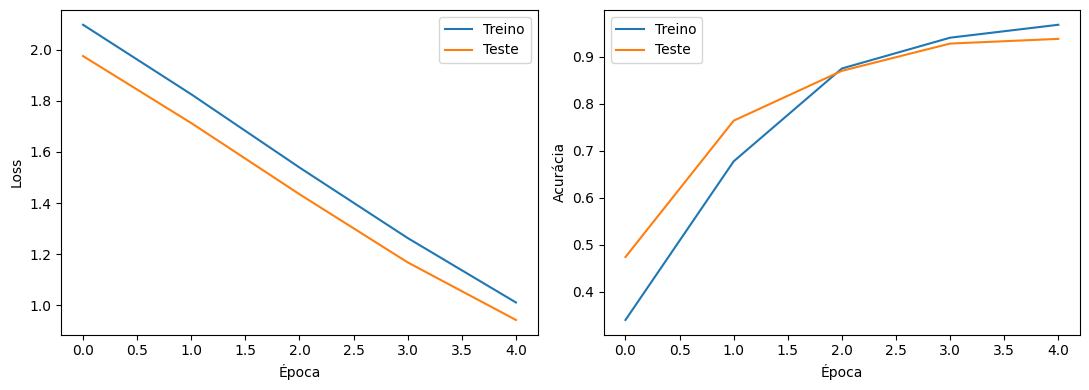

In [10]:

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(history_ideal["train_loss"], label="Treino")
ax[0].plot(history_ideal["test_loss"], label="Teste")
ax[0].set_xlabel("Época")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(history_ideal["train_acc"], label="Treino")
ax[1].plot(history_ideal["test_acc"], label="Teste")
ax[1].set_xlabel("Época")
ax[1].set_ylabel("Acurácia")
ax[1].legend()

plt.tight_layout()
plt.show()



## 7. Carregar um treinamento salvo

Esta célula permite continuar ou analisar qualquer treinamento salvo.


In [11]:

model_loaded, optimizer_loaded, history_loaded, last_epoch = carregar_checkpoint("ideal")
print(last_epoch)
print(history_loaded["test_acc"][-1])


5
0.938



## 8. IBM Quantum

A etapa seguinte mede diretamente o erro de hardware.

Para a mesma entrada e os mesmos pesos quânticos calculamos:

\[
\Delta q =
q_{\mathrm{IBM}}-q_{\mathrm{ideal}}.
\]

Esse residual inclui o efeito real observado no QPU: shots, portas imperfeitas, leitura, decoerência e transpilation.

O notebook usa o modelo na inicialização aleatória para caracterizar o ruído antes do treinamento. Para um estudo mais completo, a calibração pode ser repetida em checkpoints posteriores.


In [12]:

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator

service = QiskitRuntimeService()

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=N_QUBITS
)

print(backend.name)


ibm_fez


In [13]:

def make_qiskit_circuit(features5, weights):
    qc = QuantumCircuit(N_QUBITS)

    for q in range(N_QUBITS):
        qc.rx(float(features5[q]), q)

    for layer in range(weights.shape[0]):
        for q in range(N_QUBITS):
            phi, theta, omega = weights[layer, q]
            qc.rz(float(phi), q)
            qc.ry(float(theta), q)
            qc.rz(float(omega), q)

        r = layer + 1
        for q in range(N_QUBITS):
            qc.cx(q, (q + r) % N_QUBITS)

    return qc


Y_observables = [
    SparsePauliOp("IIIIY"),
    SparsePauliOp("IIIYI"),
    SparsePauliOp("IIYII"),
    SparsePauliOp("IYIII"),
    SparsePauliOp("YIIII")
]

pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
estimator = Estimator(mode=backend)



## 9. Validação PennyLane × Qiskit

Antes de gastar tempo no computador quântico real, verificamos se a reconstrução Qiskit produz a mesma saída do circuito PennyLane no caso ideal.


In [14]:

model_calib = HQNNParallel().to(device)
model_calib.load_state_dict(copy.deepcopy(initial_state))
model_calib.eval()

images_calib, labels_calib = next(iter(test_loader))
image_calib = images_calib[0:1].to(device)

with torch.no_grad():
    features20_t = model_calib.features20(image_calib)
    pl5 = model_calib.quantum.quantum_layers[0](features20_t[:, :5]).detach().cpu().numpy()[0]

features5 = features20_t[0, :5].detach().cpu().numpy()
weights5 = model_calib.quantum.quantum_layers[0].weights.detach().cpu().numpy()

qc = make_qiskit_circuit(features5, weights5)
state = Statevector.from_instruction(qc)
qiskit5 = np.array([np.real(state.expectation_value(obs)) for obs in Y_observables])

print(pl5)
print(qiskit5)
print(np.max(np.abs(pl5 - qiskit5)))


[-0.4299881   0.09745158 -0.03644845 -0.10814827 -0.06131064]
[-0.42998809  0.09745158 -0.03644845 -0.10814827 -0.06131064]
2.276560454039789e-09



## 10. Executar a camada quântica completa no IBM QPU

Os quatro PQCs são enviados no mesmo job. O Estimator retorna os valores de expectativa e a incerteza estatística associada à execução.


In [15]:

def quantum_weights_np(model):
    return [
        layer.weights.detach().cpu().numpy()
        for layer in model.quantum.quantum_layers
    ]


def run_quantum_layer_ibm(features20, weights4, shots=1000):
    pubs = []

    for i in range(N_CIRCUITS):
        features5 = features20[i*N_QUBITS:(i+1)*N_QUBITS]
        qc = make_qiskit_circuit(features5, weights4[i])
        isa_qc = pm.run(qc)
        isa_obs = [obs.apply_layout(isa_qc.layout) for obs in Y_observables]
        pubs.append((isa_qc, isa_obs))

    estimator.options.default_shots = shots
    job = estimator.run(pubs)
    print(job.job_id())

    result = job.result()
    means = np.concatenate([np.asarray(r.data.evs, dtype=float) for r in result])
    stds = np.concatenate([np.asarray(r.data.stds, dtype=float) for r in result])

    return means, stds



## 11. Medir uma única imagem

Aqui comparamos diretamente a saída ideal e a saída do hardware real.


In [16]:

model_calib.eval()
image = images_calib[0:1].to(device)
label = labels_calib[0].item()

with torch.no_grad():
    features20_t = model_calib.features20(image)
    q_ideal = model_calib.quantum(features20_t).detach().cpu().numpy()[0]

features20 = features20_t[0].detach().cpu().numpy()
weights4 = quantum_weights_np(model_calib)

q_ibm, q_ibm_std = run_quantum_layer_ibm(
    features20,
    weights4,
    shots=1000
)

delta_q = q_ibm - q_ideal

print("Classe:", label)
print("Ideal:", q_ideal)
print("IBM:", q_ibm)
print("Std IBM:", q_ibm_std)
print("Residual:", delta_q)


da546nc3jnrc73agrt2g
Classe: 7
Ideal: [-0.4299881   0.09745158 -0.03644845 -0.10814827 -0.06131064  0.20952848
 -0.02578148  0.18985945 -0.52733815 -0.13691705 -0.31134188  0.1439121
  0.46159238  0.0995573  -0.20974588 -0.2210188   0.10457558  0.08315278
  0.07103454  0.03686573]
IBM: [-0.3880948   0.03564136 -0.00199476 -0.04765155 -0.03558191  0.19998762
 -0.02970113  0.09973819 -0.38716883 -0.10279219 -0.26929027  0.12255992
  0.38611472  0.02393716 -0.17670782 -0.23364891  0.07709414  0.07524287
  0.05585338  0.02184029]
Std IBM: [0.02807469 0.02564563 0.03704774 0.02984837 0.03376466 0.0268186
 0.02875801 0.02957053 0.02353246 0.03106755 0.03265718 0.03852187
 0.0263037  0.0405384  0.02633631 0.02756232 0.03666041 0.03724181
 0.02756826 0.02674419]
Residual: [ 0.04189329 -0.06181022  0.03445369  0.06049672  0.02572873 -0.00954085
 -0.00391965 -0.09012126  0.14016932  0.03412486  0.04205162 -0.02135219
 -0.07547766 -0.07562013  0.03303806 -0.0126301  -0.02748144 -0.00790991
 -0.01

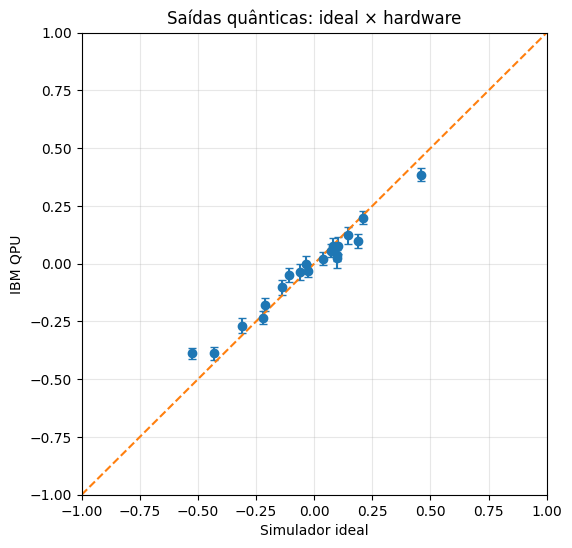

In [17]:

plt.figure(figsize=(6, 6))
plt.errorbar(q_ideal, q_ibm, yerr=q_ibm_std, fmt="o", capsize=3)
plt.plot([-1, 1], [-1, 1], "--")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel("Simulador ideal")
plt.ylabel("IBM QPU")
plt.title("Saídas quânticas: ideal × hardware")
plt.grid(alpha=0.3)
plt.show()



## 12. Construir uma distribuição empírica do ruído

Para simular treinamento em hardware real, repetimos a medição para algumas imagens e armazenamos:

\[
\Delta q=q_{\mathrm{IBM}}-q_{\mathrm{ideal}}.
\]

O treinamento ruidoso fará bootstrap desses resíduos reais.

A configuração abaixo é pequena para não consumir muitas execuções. Aumente `N_CALIB` e `N_REPEATS` para um estudo estatístico mais robusto.


In [18]:

N_CALIB = 3
N_REPEATS = 2
SHOTS = 1000

residuals = []
shot_stds = []
records = []

model_calib.eval()
weights4 = quantum_weights_np(model_calib)

for i in range(N_CALIB):
    image = test_dataset[i][0].unsqueeze(0).to(device)
    label = int(test_dataset[i][1])

    with torch.no_grad():
        features_t = model_calib.features20(image)
        ideal = model_calib.quantum(features_t).detach().cpu().numpy()[0]

    features_np = features_t[0].detach().cpu().numpy()

    for rep in range(N_REPEATS):
        measured, std = run_quantum_layer_ibm(features_np, weights4, shots=SHOTS)
        residuals.append(measured - ideal)
        shot_stds.append(std)
        records.append({"image": i, "label": label, "repeat": rep})

residuals = np.asarray(residuals)
shot_stds = np.asarray(shot_stds)

np.savez(
    OUTDIR / "ibm_noise_calibration.npz",
    residuals=residuals,
    shot_stds=shot_stds,
    records=np.array(records, dtype=object),
    shots=SHOTS
)

print(residuals.shape)
print(np.mean(residuals, axis=0))
print(np.std(residuals, axis=0, ddof=1))


da546teaa69c739ke500
da54726aa69c739ke570
da5476u1vhnc73flku0g
da547beaa69c739ke5gg
da547g3otlns739bft5g
da547ku1vhnc73flkuh0
(6, 20)
[ 0.07367666 -0.02125996 -0.00574622  0.02327606 -0.0020229  -0.03754228
 -0.01817813 -0.04850112  0.11890803  0.02963463  0.0399788  -0.04454691
 -0.0737477  -0.02231011  0.04244474  0.04509434  0.00168669  0.01943403
 -0.01686935 -0.04476437]
[0.02536084 0.03429992 0.02995406 0.04141518 0.02847647 0.05813153
 0.02242983 0.04684178 0.02257391 0.04455166 0.03106877 0.03953842
 0.00996453 0.03863554 0.02214555 0.03514568 0.02235604 0.0214064
 0.02680616 0.05154094]



## 13. Carregar a calibração IBM

Assim não é necessário repetir jobs no QPU sempre que o notebook for aberto.


In [19]:

noise_data = np.load(OUTDIR / "ibm_noise_calibration.npz", allow_pickle=True)
residuals = noise_data["residuals"]
shot_stds = noise_data["shot_stds"]

print(residuals.shape)


(6, 20)



## 14. Propagação do erro quântico em uma classificação

Usamos Monte Carlo para propagar a incerteza estatística do Estimator até as probabilidades de classe e até a loss.


In [20]:

N_MC = 10000

mu = torch.as_tensor(q_ibm, dtype=torch.float32, device=device)
sigma = torch.as_tensor(q_ibm_std, dtype=torch.float32, device=device)

q_samples = mu[None, :] + torch.randn(N_MC, N_QFEATURES, device=device) * sigma[None, :]

with torch.no_grad():
    logits_mc = model_calib.fc2(q_samples)
    probs_mc = torch.softmax(logits_mc, 1)

target_mc = torch.full((N_MC,), label, dtype=torch.long, device=device)
loss_mc = F.cross_entropy(logits_mc, target_mc, reduction="none")

prob_mean = probs_mc.mean(0).cpu().numpy()
prob_std = probs_mc.std(0).cpu().numpy()

for c in range(10):
    print(f"Classe {c}: {prob_mean[c]:.4f} ± {prob_std[c]:.4f}")

print(f"Loss: {loss_mc.mean().item():.4f} ± {loss_mc.std().item():.4f}")


Classe 0: 0.0873 ± 0.0012
Classe 1: 0.0743 ± 0.0013
Classe 2: 0.1101 ± 0.0021
Classe 3: 0.1259 ± 0.0022
Classe 4: 0.1036 ± 0.0016
Classe 5: 0.0926 ± 0.0017
Classe 6: 0.0739 ± 0.0016
Classe 7: 0.0785 ± 0.0013
Classe 8: 0.1247 ± 0.0020
Classe 9: 0.1292 ± 0.0026
Loss: 2.6005 ± 0.0180



## 15. Treinamento simulando o erro medido no IBM QPU

Agora treinamos uma segunda rede a partir da **mesma inicialização** do modelo ideal.

Em cada batch, sorteamos um residual real da calibração:

\[
q_{\mathrm{simulado\ QPU}}
=
q_{\mathrm{ideal}}
+
\Delta q_{\mathrm{IBM}}.
\]

Isso permite estudar como o ruído empírico do hardware altera convergência, loss e acurácia sem executar milhares de jobs durante todo o treinamento.

É uma aproximação: o ruído foi medido em um conjunto finito de estados do circuito. Para maior fidelidade, a calibração pode ser repetida em diferentes checkpoints do treinamento.


In [21]:

model_noisy = HQNNParallel().to(device)
model_noisy.load_state_dict(copy.deepcopy(initial_state))

model_noisy, history_noisy = treinar(
    model_noisy,
    tag="ibm_noise",
    epochs=EPOCHS,
    noise_pool=residuals
)


ibm_noise 1/5:   0%|          | 0/63 [00:00<?, ?it/s]

train loss=2.1063 acc=0.3430 | test loss=1.9821 acc=0.5700


ibm_noise 2/5:   0%|          | 0/63 [00:00<?, ?it/s]

train loss=1.8282 acc=0.7725 | test loss=1.6900 acc=0.8880


ibm_noise 3/5:   0%|          | 0/63 [00:00<?, ?it/s]

train loss=1.5283 acc=0.9200 | test loss=1.3849 acc=0.9220


ibm_noise 4/5:   0%|          | 0/63 [00:00<?, ?it/s]

train loss=1.2302 acc=0.9515 | test loss=1.1045 acc=0.9300


ibm_noise 5/5:   0%|          | 0/63 [00:00<?, ?it/s]

train loss=0.9499 acc=0.9660 | test loss=0.8644 acc=0.9520



## 16. Comparação final

O experimento principal compara o treinamento ideal com o treinamento que recebe resíduos medidos no computador quântico real.


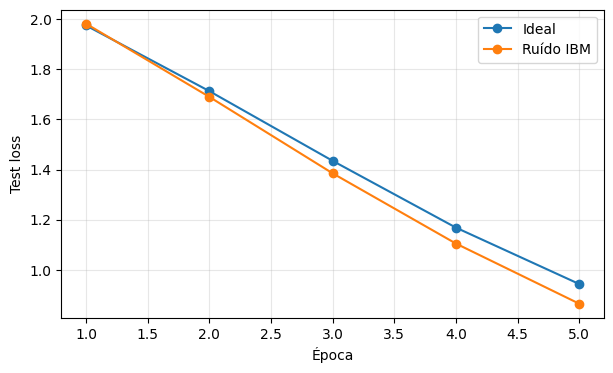

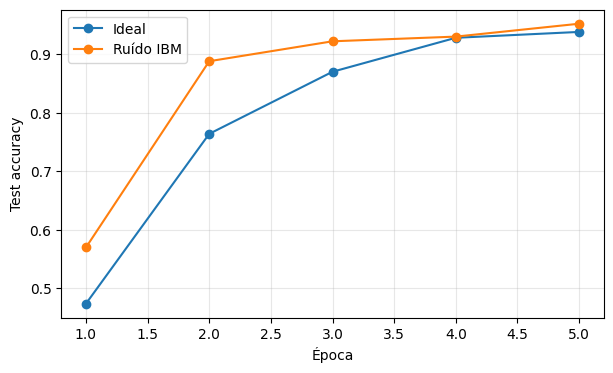

In [22]:

epochs_axis = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, history_ideal["test_loss"], marker="o", label="Ideal")
plt.plot(epochs_axis, history_noisy["test_loss"], marker="o", label="Ruído IBM")
plt.xlabel("Época")
plt.ylabel("Test loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, history_ideal["test_acc"], marker="o", label="Ideal")
plt.plot(epochs_axis, history_noisy["test_acc"], marker="o", label="Ruído IBM")
plt.xlabel("Época")
plt.ylabel("Test accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [23]:

print("Ideal")
print("Loss:", history_ideal["test_loss"][-1])
print("Accuracy:", history_ideal["test_acc"][-1])

print("\nRuído IBM")
print("Loss:", history_noisy["test_loss"][-1])
print("Accuracy:", history_noisy["test_acc"][-1])


Ideal
Loss: 0.9429638557434082
Accuracy: 0.938

Ruído IBM
Loss: 0.8644043655395508
Accuracy: 0.952



## 17. Carregar o modelo treinado com ruído IBM


In [24]:

model_ibm_loaded, optimizer_ibm_loaded, history_ibm_loaded, last_epoch_ibm = carregar_checkpoint("ibm_noise")
print(last_epoch_ibm)
print(history_ibm_loaded["test_acc"][-1])


5
0.952



## Interpretação para a apresentação

O modelo ideal fornece o controle sem ruído. O QPU real é utilizado para medir diretamente a diferença entre a saída quântica ideal e a saída observada em hardware. Esses resíduos formam uma distribuição empírica do erro.

A segunda rede é treinada com os mesmos pesos iniciais, mas recebe amostras dessa distribuição na saída dos PQCs. Assim podemos comparar, de forma controlada, como o ruído medido em um computador quântico real afeta a convergência e a classificação.

A propagação Monte Carlo usa as incertezas estatísticas retornadas pelo Estimator para transformar incerteza em \(\langle Y
angle\) em incerteza nas probabilidades de classe e na loss.

Para um estudo mais rigoroso de treinamento físico, o próximo passo seria medir também gradientes por parameter-shift diretamente no QPU. O presente notebook modela a perturbação real observada no forward quântico, que já permite um experimento prático e apresentável.
